
<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
Digital Image Processing <br>
<font color=2565AE size=5>
Department Of Mathematical Sciences <br>
Spring 2025<br>
<font color=3C99D size=5>
Assignment 2 <br>
</div>


---



### Full Name : Kasra Siavashpour
### Student Number :99109903
___

In [2]:
# DO NOT MODIFY THIS CELL
import numpy as np
import cv2
from matplotlib import pyplot as plt
import skimage.metrics
from scipy.fftpack import dct, idct

## **Q1: DFT Transformation**

**DFT transform**

In [3]:
def dft(image):
  '''
  function for applying DFT tranform.
  Hint:
    https://numpy.org/doc/stable/reference/generated/numpy.fft.fft2.html

  input(s):
    image (ndarray): input image
  output (s):
    output_image (ndarray): transformed image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output_image = np.fft.fft2(image)

  ###############################################
  return output_image

def shift_fft(dft):
  '''
  function for shifting tranformed image.
  Hint:
    https://numpy.org/doc/stable/reference/generated/numpy.fft.fftshift.html

  input(s):
    dft (ndarray): input trandformed image
  output (s):
    output_image (ndarray): shifted transformed image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output_image = np.fft.fftshift(dft)

  ###############################################
  return output_image

def inverse_shift(shifted_image):
  '''
  function for inverting shift DFT.
  Hint:
    https://numpy.org/doc/stable/reference/generated/numpy.fft.ifftshift.html

  input(s):
    shifted_image (ndarray): input shifted image
  output (s):
    output_image (ndarray): inverse shifted image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output_image = np.fft.ifftshift(shifted_image)

  ###############################################
  return output_image


def idft(image):
  '''
  function for applying IDFT tranform.
  Hint:
    https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft2.html

  input(s):
    image (ndarray): input image
  output (s):
    output_image (ndarray): inverse transformed image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

  output_image = np.fft.ifft2(image)


  ###############################################
  return output_image



Automatically detected notch centers: [(118, 118), (118, 138), (138, 118), (138, 138)]


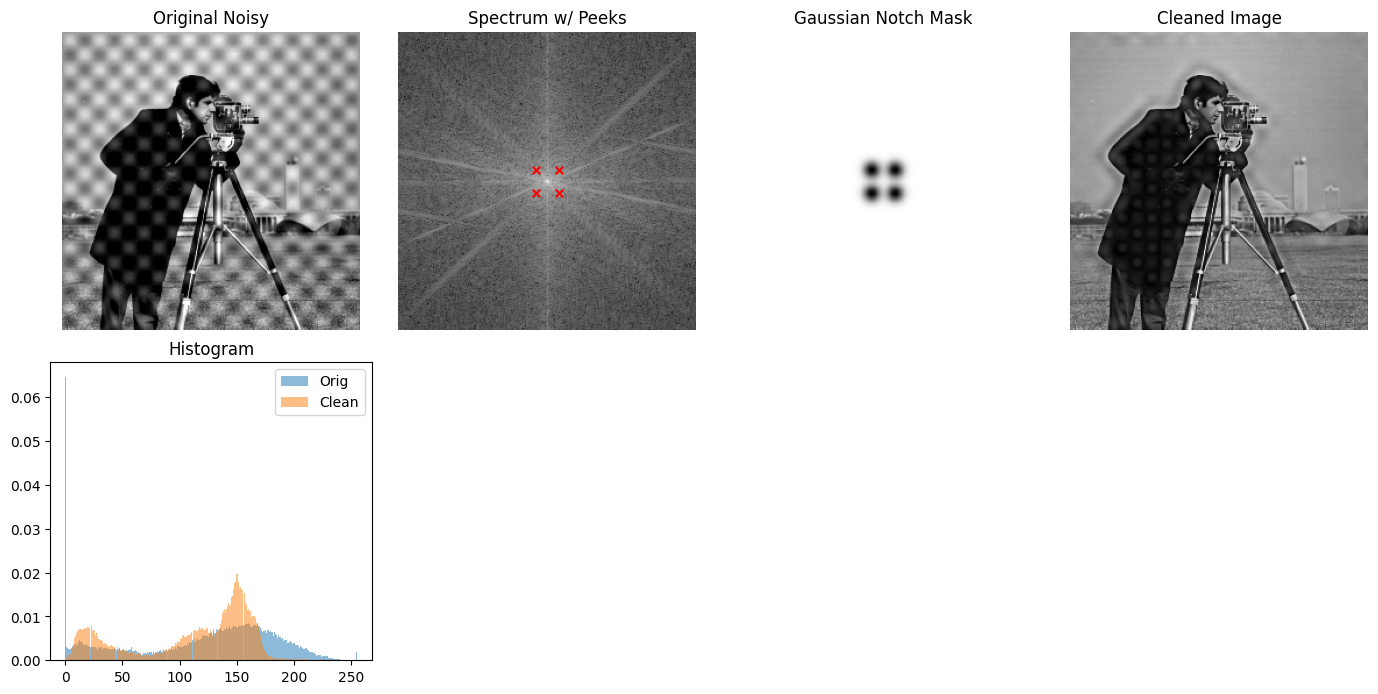

Saved: Q1-outputs/1-1-1-1-cleaned-periodic-noise.png


In [4]:
def auto_detect_notch_centers(dft_img, threshold_percentile=99.9, dc_radius=11):
    """
    Find all peaks above the given percentile (excluding a small DC disk),
    then add their symmetric counterparts around the center.
    Returns a list of (row, col) notch centers.
    """
    F = shift_fft(dft_img)
    mag = np.abs(F)
    # zero-out the DC region so we don't pick the main lobe
    cy, cx = np.array(mag.shape) // 2
    Y, X = np.ogrid[:mag.shape[0], :mag.shape[1]]
    dc_mask = (X - cx)**2 + (Y - cy)**2 <= dc_radius**2
    mag[dc_mask] = 1

    # threshold
    thresh = np.percentile(mag, threshold_percentile)
    peaks = np.argwhere(mag > thresh)

    centers = set()
    for (r, c) in peaks:
        centers.add((int(r), int(c)))
        # add symmetric
        sy = 2*cy - r
        sx = 2*cx - c
        centers.add((int(sy), int(sx)))

    return sorted(centers)


def gaussian_notch_mask(shape, centers, sigma=4, keep_dc_radius=11):
    rows, cols = shape
    cy, cx = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]

    mask = np.ones(shape, np.float32)
    # protect DC
    dc_disc = (X - cx)**2 + (Y - cy)**2 <= keep_dc_radius**2
    mask[dc_disc] = 1

    for (py, px) in centers:
        dist2 = (X - px)**2 + (Y - py)**2
        mask *= (1.0 - np.exp(-dist2 / (2 * sigma**2)))

    return mask


def remove_periodic_noise_auto(image, threshold_percentile=99.9,
                               sigma=4, dc_radius=30, do_denoise=True):
    """
    Fully automatic periodic-noise removal:
     1) detect notch centers via threshold_percentile
     2) build Gaussian-notch mask
     3) apply & inverse DFT
     4) optional median denoise
    """
    img_f = image.astype(np.float32)
    F = dft(img_f)
    centers = auto_detect_notch_centers(F, threshold_percentile, dc_radius)
    Fs = shift_fft(F)
    mask = gaussian_notch_mask(Fs.shape, centers, sigma, dc_radius)
    F_filtered = Fs * mask
    cleaned = idft(inverse_shift(F_filtered)).real

    if do_denoise:
        cleaned = cv2.medianBlur(cleaned.astype(np.float32), 4)

    cleaned = np.clip(cleaned, 0, 255).astype(image.dtype)
    return cleaned, mask, np.log(np.abs(Fs) + 1), centers


def visualize_noise_removal(original_image, cleaned_image, magnitude_spectrum, mask, centers):
    plt.figure(figsize=(14, 7))

    plt.subplot(2, 4, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Noisy')
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.scatter([c for (_, c) in centers], [r for (r, _) in centers],
                s=30, c='r', marker='x')
    plt.title('Spectrum w/ Peeks')
    plt.axis('off')

    plt.subplot(2, 4, 3)
    plt.imshow(mask, cmap='gray')
    plt.title('Gaussian Notch Mask')
    plt.axis('off')

    plt.subplot(2, 4, 4)
    plt.imshow(cleaned_image, cmap='gray')
    plt.title('Cleaned Image')
    plt.axis('off')

    # plt.subplot(2, 4, 5)
    # diff = np.abs(original_image.astype(float) - cleaned_image.astype(float))
    # plt.imshow(diff, cmap='hot')
    # plt.title('Difference')
    # plt.axis('off')

    plt.subplot(2, 4, 5)
    plt.hist(original_image.ravel(), bins=256, alpha=0.5, label='Orig', density=True)
    plt.hist(cleaned_image.ravel(), bins=256, alpha=0.5, label='Clean', density=True)
    plt.title('Histogram')
    plt.legend()

    plt.tight_layout()
    plt.show()




img = cv2.imread('Images/periodic_noise.png',
                    cv2.IMREAD_GRAYSCALE)

clean, mask, spec, centers = remove_periodic_noise_auto(
    img,
    threshold_percentile=99.995,
    sigma=5,
    dc_radius=14,
    do_denoise=False
)
print("Automatically detected notch centers:", centers)
visualize_noise_removal(img, clean, spec, mask, centers)


if clean.max() <= 1.0:
    to_save = (clean * 255).clip(0, 255).astype(np.uint8)
else:
    to_save = clean.clip(0, 255).astype(np.uint8)
output_dir = 'Q1-outputs'
import os
os.makedirs(output_dir, exist_ok=True)  # ensure directory exists
output_path = os.path.join(output_dir, "1-1-1-1-cleaned-periodic-noise.png")
cv2.imwrite(output_path, to_save)
print(f"Saved: {output_path}")    

**DCT transform**

In [5]:
def dct_transform(image):
  '''
  function for applying DCT tranform.
  Set:
    transposed function as an input
    type = 2
    norm = 'ortho'
  Hint:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.fftpack.dct.html

  input(s):
    image (ndarray): input image
  output (s):
    output_image (ndarray): transformed image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

    # Apply DCT to rows
  dct_rows = dct(image.T, type=2, norm='ortho')
    # Apply DCT to columns (after transpose)
  output_image = dct(dct_rows.T, type=2, norm='ortho')
  ###############################################
  return output_image


def idct_transform(dct):
  '''
  function for inverting transformed image.
  Set:
    transposed function as an input
    type = 2
    norm = 'ortho'
  Hint:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.fftpack.idct.html

  input(s):
    dct (ndarray): input trandformed image
  output (s):
    output_image (ndarray): inverted transformed image
  '''
  ###############################################
  ############# YOUR CODE GOES HERE #############

    # Apply inverse DCT to rows
  idct_rows = idct(dct.T, type=2, norm='ortho')
    # Apply inverse DCT to columns (after transpose)
  output_image = idct(idct_rows.T, type=2, norm='ortho')
  ###############################################
  return output_image

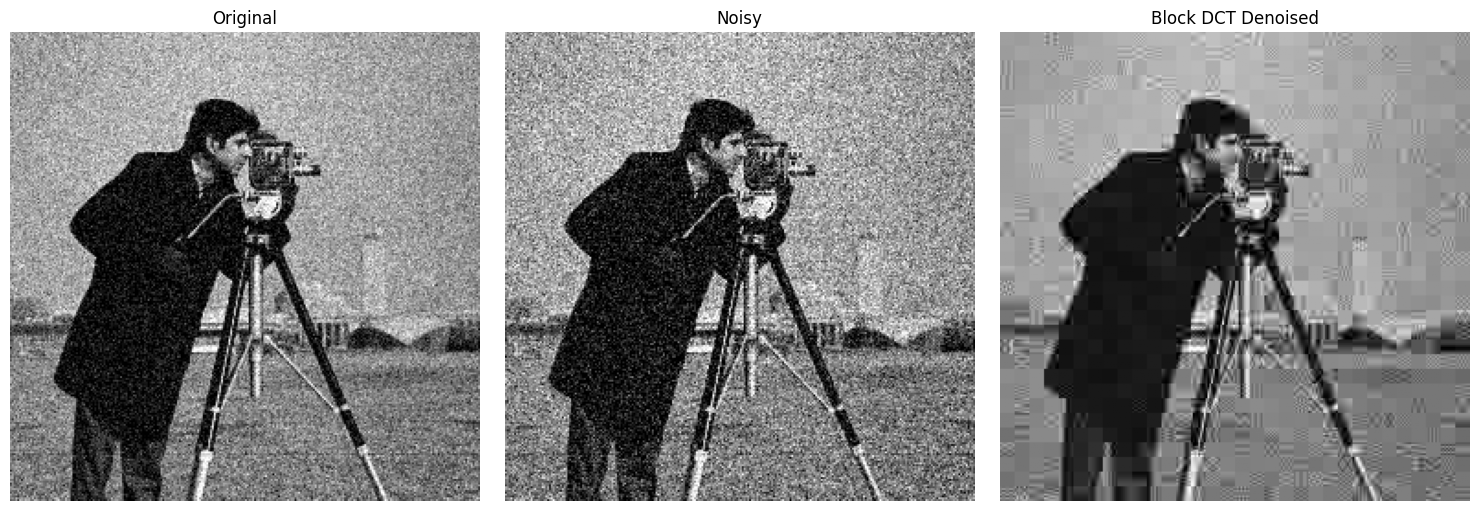

In [6]:

def blockwise_dct(img, block_size=16, threshold=30):
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.float64)
    
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = img[i:i+block_size, j:j+block_size]
            # Pad block if not full size
            if block.shape != (block_size, block_size):
                padded = np.zeros((block_size, block_size))
                padded[:block.shape[0], :block.shape[1]] = block
                block = padded

            # Apply DCT
            dct_block = dct(dct(block.T, norm='ortho').T, norm='ortho')
            
            # Threshold small values
            dct_block[np.abs(dct_block) < threshold] = 0
            
            # Apply inverse DCT
            idct_block = idct(idct(dct_block.T, norm='ortho').T, norm='ortho')
            
            # Store result
            output[i:i+block_size, j:j+block_size] = idct_block[:block.shape[0], :block.shape[1]]
    
    return np.clip(output, 0, 255).astype(np.uint8)

# Example usage
image_path = "Images/white_noise.png"  # replace with your image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Add synthetic white noise
np.random.seed(42)
noisy_img = img + np.random.normal(0, 25, img.shape)
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

# Apply block-wise DCT denoising
denoised = blockwise_dct(noisy_img, block_size=8, threshold=100)

# Show results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Block DCT Denoised")
plt.imshow(denoised, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


## **Q2: Image Cartoonization**

One of the applications of bilateral filters is for adding cartoon effects to color images. In this question we are going to implement the code to cartoonize a given image.

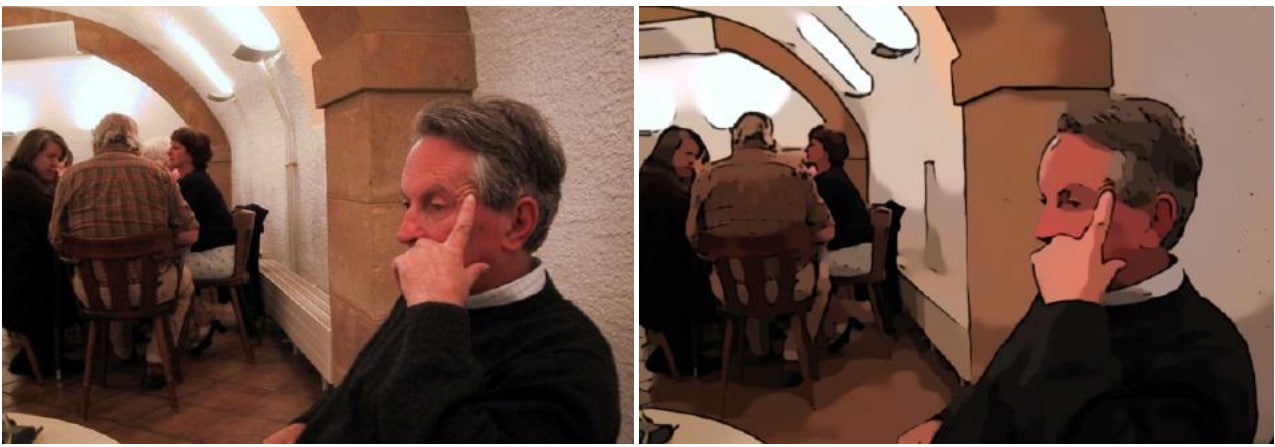

Steps for adding Cartoon effect to the given color image `img`:


1.   Blur `img` using any method you prefer to get `img_blur`.
2.   Use any edge detection method on `img_blur` to get a single channel image `img_edge`, containing the edges.
3.   Apply bilateral filter on the original image `img` to get `img_bf`.
4.   Mix `img_bf` and `img_edges` to get the desired cartoonized image.



### Step 1: Edge Detection

Implement `edge_detection` function to get a colored image as input and output a gray image indicating the edges. You are free to use any method you want or use existing functions from `opencv`.

In [30]:
def edge_detection(img: np.ndarray):
    """
    Detect edges in a color image and return a single-channel grayscale edge image.
    We use a median blur + adaptive threshold method for better cartoon-like edges.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 21)
    edges = cv2.adaptiveThreshold(blurred, 255,
                                   cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY,
                                   blockSize=13,
                                   C=5)
    return edges


Now, Apply the method on `Q2-input.jpg` and save the result as `Q2-output-edges.jpg`. Your score on this part depends on the quality of the result.

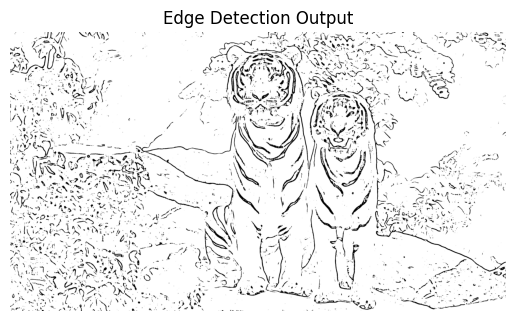

In [31]:
# Load the input image
img = cv2.imread('Q2-input.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Detect edges
img_edges = edge_detection(img)

# Save edge result
cv2.imwrite('Q2-output-edges.jpg', img_edges)

# Display edge image
plt.imshow(img_edges, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')
plt.show()


### Step 2: Bilateral Filter

Implement Bilateral filter. This function should be implemented from scratch and you are not allowed to use any existing function or library other than `numpy`.

In [32]:
import numpy as np

def bilateral_filter(img: np.ndarray, d: int, sigma_space: float, sigma_color: float):
    """
    Apply bilateral filter to an image using NumPy only.
    
    Parameters:
    - img: Input image (grayscale or color) as np.ndarray
    - d: Diameter of each pixel neighborhood (should be odd)
    - sigma_space: Spatial Gaussian standard deviation
    - sigma_color: Color (intensity) Gaussian standard deviation
    
    Returns:
    - Filtered image as np.ndarray (same shape as input)
    """
    if d % 2 == 0:
        d += 1  # Ensure window size is odd
    radius = d // 2

    # Prepare output
    filtered_img = np.zeros_like(img, dtype=np.float64)

    # Spatial Gaussian kernel (same for all pixels)
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma_space**2))

    # Pad the image
    if img.ndim == 2:  # Grayscale
        padded_img = np.pad(img, ((radius, radius), (radius, radius)), mode='reflect')
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                region = padded_img[i:i+d, j:j+d]
                intensity_diff = region - img[i, j]
                range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_color**2))
                bilateral_weights = spatial_kernel * range_kernel
                normalized = bilateral_weights / bilateral_weights.sum()
                filtered_img[i, j] = np.sum(region * normalized)
    else:  # Color image
        padded_img = np.pad(img, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                for c in range(img.shape[2]):
                    region = padded_img[i:i+d, j:j+d, c]
                    intensity_diff = region - img[i, j, c]
                    range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_color**2))
                    bilateral_weights = spatial_kernel * range_kernel
                    normalized = bilateral_weights / bilateral_weights.sum()
                    filtered_img[i, j, c] = np.sum(region * normalized)

    return np.clip(filtered_img, 0, 255).astype(np.uint8)


Apply this function on `Q2-input.jpg` and save the result as `Q2-output-bf.jpg`. Use parameters by your choice to get a proper result (blurring should be noticable, but not too much) Your score on this part depends on the quality of the result.

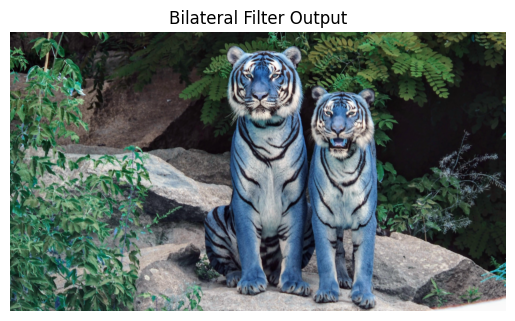

In [33]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- Step 1: Load the image ---
img = cv2.imread("Q2-input.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert for display
img = img.astype(np.float64)  # Ensure float64 for precision

# --- Step 2: Apply custom bilateral filter ---
filtered = bilateral_filter(img, d=7, sigma_space=5.0, sigma_color=40.0)

# --- Step 3: Save the result ---
output_bgr = cv2.cvtColor(filtered, cv2.COLOR_RGB2BGR)
cv2.imwrite("Q2-output-bf.jpg", output_bgr)

# --- Step 4: Display result ---
plt.imshow(filtered)
plt.title("Bilateral Filter Output")
plt.axis("off")
plt.show()


### Step 3: Image Cartoonization

Use the previous functions to implement `cartoonize` function. This function takes a colored image `img` and a real number $\alpha$ as input. $\alpha$ will be a real number between 0 and 1, indicating the intensity of cartoonization. $\alpha=0$ means minimal cartoonization; output should be the original image (or very close to it) and as $\alpha$ approaches to 1, cartoonization should be more intense. Note that the dimensionality of the result should be the same as the input. Your score on this part depends on the quality of the result.

In [34]:
def cartoonize(img: np.ndarray, alpha: float):
    """
    Apply cartoon effect to a color image using edge detection and bilateral filtering.
    
    Parameters:
    - img: Input color image as np.ndarray
    - alpha: Float in [0, 1], determines cartoonization intensity
    
    Returns:
    - cartoon_img: Cartoonized version of the image (same shape as input)
    """
    assert 0.0 <= alpha <= 1.0, "Alpha must be between 0 and 1"
    
    # Step 1: Edge Detection
    edges = edge_detection(img)  # returns 1-channel
    edges_3ch = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)  # match color dims

    # Step 2: Bilateral Filter
    img_float = img.astype(np.float64)
    img_bf = bilateral_filter(img_float, d=16, sigma_space=200, sigma_color=100)

    # Step 3: Combine edge mask and filtered image (simulate cartoon)
    cartoon = cv2.bitwise_and(img_bf, edges_3ch)

    # Step 4: Blend with original image based on alpha
    blended = ((1 - alpha) * img + alpha * cartoon).astype(np.uint8)

    return blended


Apply the method on `Q2-input.jpg` for $\alpha=0, 0.25, 0.5, 1$ and save the results as `Q2-output-0.jpg`, `Q2-output-1.jpg`,`Q2-output-2.jpg` and `Q2-output-3.jpg`, respectively.

In [35]:
# Load input image
img_bgr = cv2.imread("Q2-input.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Alpha values and corresponding output names
alphas = [0.0, 0.25, 0.5, 1.0]
output_names = ["Q2-output-0.jpg", "Q2-output-1.jpg", "Q2-output-2.jpg", "Q2-output-3.jpg"]

# Apply cartoonize for each alpha and save result
for alpha, name in zip(alphas, output_names):
    cartoon = cartoonize(img_rgb, alpha)
    cartoon_bgr = cv2.cvtColor(cartoon, cv2.COLOR_RGB2BGR)
    cv2.imwrite(name, cartoon_bgr)
    print(f"Saved: {name}")


Saved: Q2-output-0.jpg
Saved: Q2-output-1.jpg
Saved: Q2-output-2.jpg
Saved: Q2-output-3.jpg
